In [2]:
from numpy import pi
import pint
from simulation import SimulationConfig, OpticalForceCalculator, DipoleCalculator, SweepRunner
import numpy as np
ureg = pint.UnitRegistry()
import matplotlib.pyplot as plt


/Users/semyon_b/git/Mie_SPP_Force-CRACKED/.venv/lib/python3.14/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
baseConfig = SimulationConfig(
    wl=640 * ureg.nanometer,
    R=100 * ureg.nanometer,
    dist=10 * ureg.nanometer,
    angle=np.deg2rad(25),
    psi=pi/2,
    chi=pi/4,
    substrate='Air',
    particle='SiO2',
    amplitude=1,
    show_warnings=False,
    initial_field_type='custom',
    z_beam=100,
    w0=200
)

# dips = OpticalForceCalculator(baseConfig).compute()

R_arr = np.linspace(10, 170, 50) * ureg.nanometer

res, _, _ = SweepRunner(baseConfig, 'R', R_arr, compute_force=True).run()

Custom field parameters set: w0=200, z_beam=100


100%|██████████| 50/50 [00:05<00:00,  8.60it/s]


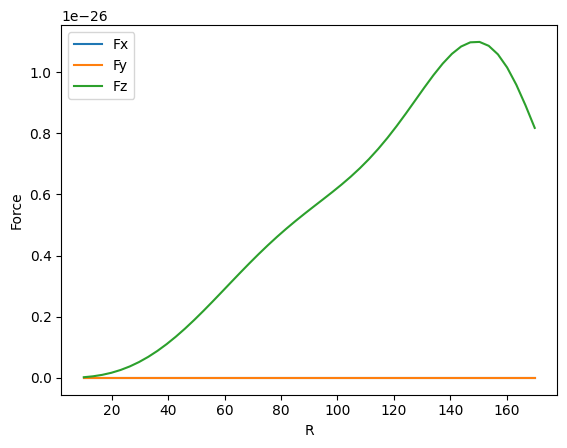

In [4]:
plt.plot(res.R, res.Fx, label='Fx')
plt.plot(res.R, res.Fy, label='Fy')
plt.plot(res.R, res.Fz, label='Fz')
plt.xlabel('R')
plt.ylabel('Force')
plt.legend()
plt.show()